# Task 5 Gate Tester

This notebook loads one or more Task 5 input parquet files for a selected station, derives simple strip-topology columns, applies notebook-defined gates, prints the available columns, and provides plotting helpers for gate comparisons. Edit the configuration cells and rerun from the top.

## 1. Select Station and Files

`JOIN_TARGET_FILES` and `JOIN_WINDOW_HOURS` follow the same idea as the task scripts: start from one selected file, then add nearby files from the same station when their basename timestamp is inside the configured window. If there are fewer compatible files, the notebook uses as many as it can, including only the selected file.

In [76]:
from datetime import datetime, timedelta
from pathlib import Path
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path("/home/mingo/DATAFLOW_v3")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 100)

_ORDER_SUFFIXES = (
    ".hld.tar.gz", ".hld-tar-gz", ".tar.gz", ".hld", ".parquet",
    ".dat", ".root", ".list", ".lis", ".fit", ".corr",
)

def strip_order_suffixes(name: str) -> str:
    lowered = name.lower()
    for suffix in _ORDER_SUFFIXES:
        if lowered.endswith(suffix):
            return strip_order_suffixes(name[: -len(suffix)])
    return name

def normalize_processing_prefix(name: str) -> str:
    lowered = name.lower()
    if lowered.startswith("mini"):
        return "mi01" + lowered[4:]
    return lowered

def extract_run_datetime_from_name(file_name: str):
    base = strip_order_suffixes(file_name)
    normalized = normalize_processing_prefix(base)
    match = re.search(r"(\d{11})$", normalized)
    if not match:
        return None
    stamp = match.group(1)
    try:
        yy = int(stamp[0:2])
        day_of_year = int(stamp[2:5])
        hour = int(stamp[5:7])
        minute = int(stamp[7:9])
        second = int(stamp[9:11])
    except ValueError:
        return None
    if not (1 <= day_of_year <= 366):
        return None
    if not (0 <= hour <= 23 and 0 <= minute <= 59 and 0 <= second <= 59):
        return None
    try:
        return datetime(2000 + yy, 1, 1) + timedelta(
            days=day_of_year - 1,
            hours=hour,
            minutes=minute,
            seconds=second,
        )
    except ValueError:
        return None

def select_joined_file_names(selected_file_name, candidate_file_names, *, max_files, tolerance_hours, selection_order="latest"):
    if int(max_files) <= 1:
        return [selected_file_name]
    selected_datetime = extract_run_datetime_from_name(selected_file_name)
    if selected_datetime is None:
        print(f"Joined file selection disabled: could not parse timestamp from {selected_file_name}.")
        return [selected_file_name]

    tolerance = pd.Timedelta(hours=float(tolerance_hours))
    prefer_older = str(selection_order).strip().lower() not in {"oldest", "fifo", "first"}
    candidate_rows = []
    for candidate_name in candidate_file_names:
        if candidate_name == selected_file_name:
            continue
        candidate_datetime = extract_run_datetime_from_name(candidate_name)
        if candidate_datetime is None:
            continue
        delta = pd.Timestamp(selected_datetime) - pd.Timestamp(candidate_datetime)
        if prefer_older:
            if delta < pd.Timedelta(0) or delta > tolerance:
                continue
        else:
            if delta > pd.Timedelta(0) or abs(delta) > tolerance:
                continue
        candidate_rows.append((abs(delta), candidate_name))

    candidate_rows.sort(key=lambda item: item[0])
    selected_names = [selected_file_name, *[name for _delta, name in candidate_rows[: int(max_files) - 1]]]
    selected_names.sort(key=lambda name: extract_run_datetime_from_name(name) or datetime.min)
    print(
        "Joined file selection: "
        f"requested={int(max_files)} selected={len(selected_names)} "
        f"tolerance_hours={float(tolerance_hours):g} files={selected_names}"
    )
    return selected_names

# Edit these values.
STATION = 1
JOIN_TARGET_FILES = 3
JOIN_WINDOW_HOURS = 8.0
SELECTION_ORDER = "latest"  # "latest" or "oldest"
RANDOM_SEED = None

station_name = f"MINGO{int(STATION):02d}"
task5_input_root = REPO_ROOT / "STATIONS" / station_name / "STAGE_1" / "EVENT_DATA" / "STEP_1" / "TASK_5" / "INPUT_FILES"
search_subdirs = [
    "UNPROCESSED_DIRECTORY",
    "COMPLETED_DIRECTORY",
    "PROCESSING_DIRECTORY",
    "ERROR_DIRECTORY",
]

candidate_paths = []
for subdir in search_subdirs:
    directory = task5_input_root / subdir
    if directory.exists():
        candidate_paths.extend(sorted(directory.glob("*.parquet")))

candidate_paths = sorted(set(candidate_paths), key=lambda p: p.name)
if not candidate_paths:
    raise FileNotFoundError(f"No Task 5 input parquet files found under {task5_input_root}")

rng = random.Random(RANDOM_SEED)
if SELECTION_ORDER.lower() in {"latest", "newest"}:
    selected_path = candidate_paths[-1]
elif SELECTION_ORDER.lower() in {"oldest", "fifo", "first"}:
    selected_path = candidate_paths[0]
else:
    selected_path = rng.choice(candidate_paths)

paths_by_name = {path.name: path for path in candidate_paths}
selected_names = select_joined_file_names(
    selected_path.name,
    paths_by_name.keys(),
    max_files=int(JOIN_TARGET_FILES),
    tolerance_hours=float(JOIN_WINDOW_HOURS),
    selection_order=SELECTION_ORDER,
)
selected_paths = [paths_by_name[name] for name in selected_names if name in paths_by_name]

print(f"Station: {station_name}")
print(f"Selected {len(selected_paths)} file(s):")
for path in selected_paths:
    print(f"  {path}")

frames = []
for path in selected_paths:
    frame = pd.read_parquet(path)
    frame["notebook_source_file"] = path.name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True) if len(frames) > 1 else frames[0].copy()
print(f"Loaded rows={len(df):,}, columns={len(df.columns):,}")
display(df.head())

Joined file selection: requested=3 selected=3 tolerance_hours=8 files=['fitted_mi0126033132456.parquet', 'fitted_mi0126033140358.parquet', 'fitted_mi0126033144249.parquet']
Station: MINGO01
Selected 3 file(s):
  /home/mingo/DATAFLOW_v3/STATIONS/MINGO01/STAGE_1/EVENT_DATA/STEP_1/TASK_5/INPUT_FILES/COMPLETED_DIRECTORY/fitted_mi0126033132456.parquet
  /home/mingo/DATAFLOW_v3/STATIONS/MINGO01/STAGE_1/EVENT_DATA/STEP_1/TASK_5/INPUT_FILES/COMPLETED_DIRECTORY/fitted_mi0126033140358.parquet
  /home/mingo/DATAFLOW_v3/STATIONS/MINGO01/STAGE_1/EVENT_DATA/STEP_1/TASK_5/INPUT_FILES/COMPLETED_DIRECTORY/fitted_mi0126033144249.parquet
Loaded rows=63,350, columns=336


,datetime,event_id,acquisition_type,p4_s1_ef_t,p4_s2_ef_t,p4_s3_ef_t,p4_s4_ef_t,p4_s1_eb_t,p4_s2_eb_t,p4_s3_eb_t,p4_s4_eb_t,p4_s1_ef_q,p4_s2_ef_q,p4_s3_ef_q,p4_s4_ef_q,p4_s1_eb_q,p4_s2_eb_q,p4_s3_eb_q,p4_s4_eb_q,p3_s1_ef_t,p3_s2_ef_t,p3_s3_ef_t,p3_s4_ef_t,p3_s1_eb_t,p3_s2_eb_t,p3_s3_eb_t,p3_s4_eb_t,p3_s1_ef_q,p3_s2_ef_q,p3_s3_ef_q,p3_s4_ef_q,p3_s1_eb_q,p3_s2_eb_q,p3_s3_eb_q,p3_s4_eb_q,p2_s1_ef_t,p2_s2_ef_t,p2_s3_ef_t,p2_s4_ef_t,p2_s1_eb_t,p2_s2_eb_t,p2_s3_eb_t,p2_s4_eb_t,p2_s1_ef_q,p2_s2_ef_q,p2_s3_ef_q,p2_s4_ef_q,p2_s1_eb_q,p2_s2_eb_q,p2_s3_eb_q,p2_s4_eb_q,p1_s1_ef_t,p1_s2_ef_t,p1_s3_ef_t,p1_s4_ef_t,p1_s1_eb_t,p1_s2_eb_t,p1_s3_eb_t,p1_s4_eb_t,p1_s1_ef_q,p1_s2_ef_q,p1_s3_ef_q,p1_s4_ef_q,p1_s1_eb_q,p1_s2_eb_q,p1_s3_eb_q,p1_s4_eb_q,param_hash,tt_task0_acq,topology_task1_channel,tt_task0_raw,transferred_task0_acq_to_raw,filter_task1_problematic_channel_count,filter_task1_problematic_channel_exact,tt_task1_clean,transferred_task1_raw_to_clean,p1_s1_tsum,p1_s1_tdif,p1_s1_qsum,p1_s1_qdif,p1_s2_tsum,p1_s2_tdif,p1_s2_qsum,p1_s2_qdif,p1_s3_tsum,p1_s3_tdif,p1_s3_qsum,p1_s3_qdif,p1_s4_tsum,p1_s4_tdif,p1_s4_qsum,p1_s4_qdif,p2_s1_tsum,p2_s1_tdif,p2_s1_qsum,p2_s1_qdif,p2_s2_tsum,p2_s2_tdif,p2_s2_qsum,p2_s2_qdif,p2_s3_tsum,p2_s3_tdif,p2_s3_qsum,p2_s3_qdif,p2_s4_tsum,p2_s4_tdif,p2_s4_qsum,p2_s4_qdif,p3_s1_tsum,p3_s1_tdif,p3_s1_qsum,p3_s1_qdif,p3_s2_tsum,p3_s2_tdif,p3_s2_qsum,p3_s2_qdif,p3_s3_tsum,p3_s3_tdif,p3_s3_qsum,p3_s3_qdif,p3_s4_tsum,p3_s4_tdif,p3_s4_qsum,p3_s4_qdif,p4_s1_tsum,...,event_det_th_chi,event_det_tt_task3_list,event_det_t0,event_tim_x,event_tim_xp,event_tim_y,event_tim_yp,event_tim_t0,event_tim_s,event_tim_th_chi,event_tim_res_y,event_tim_res_ts,event_tim_res_td,event_tim_tt_task3_list,event_tim_res_ystr_1,event_tim_res_ystr_2,event_tim_res_ystr_3,event_tim_res_ystr_4,event_tim_res_tsum_1,event_tim_res_tsum_2,event_tim_res_tsum_3,event_tim_res_tsum_4,event_tim_res_tdif_1,event_tim_res_tdif_2,event_tim_res_tdif_3,event_tim_res_tdif_4,event_tim_ext_res_ystr_1,event_tim_ext_res_ystr_2,event_tim_ext_res_ystr_3,event_tim_ext_res_ystr_4,event_tim_ext_res_tsum_1,event_tim_ext_res_tsum_2,event_tim_ext_res_tsum_3,event_tim_ext_res_tsum_4,event_tim_ext_res_tdif_1,event_tim_ext_res_tdif_2,event_tim_ext_res_tdif_3,event_tim_ext_res_tdif_4,event_tim_p1_qsum,event_tim_p2_qsum,event_tim_p3_qsum,event_tim_p4_qsum,event_tim_event_charge,event_tim_timtrack_iterations,event_tim_timtrack_conv_distance,event_tim_timtrack_converged,event_tim_charge_1,event_tim_charge_2,event_tim_charge_3,event_tim_charge_4,th_chisq_df_0,th_chisq_df_3,th_chisq_df_6,event_tim_theta,event_tim_phi,event_xp,event_yp,p1_ystr_res,p1_tsum_res,p1_tdif_res,p1_ystr_res_ext,p1_tsum_res_ext,p1_tdif_res_ext,p2_ystr_res,p2_tsum_res,p2_tdif_res,p2_ystr_res_ext,p2_tsum_res_ext,p2_tdif_res_ext,p3_ystr_res,p3_tsum_res,p3_tdif_res,p3_ystr_res_ext,p3_tsum_res_ext,p3_tdif_res_ext,p4_ystr_res,p4_tsum_res,p4_tdif_res,p4_ystr_res_ext,p4_tsum_res_ext,p4_tdif_res_ext,event_charge,timtrack_iterations,timtrack_conv_distance,timtrack_converged,event_x,event_x_err,event_y,event_y_err,event_theta,event_theta_err,event_phi,event_phi_err,event_s,event_t0,event_t0_err,p1_ystr_res_err,p2_ystr_res_err,p3_ystr_res_err,p4_ystr_res_err,p1_tsum_res_err,p2_tsum_res_err,p3_tsum_res_err,p4_tsum_res_err,p1_tdif_res_err,p2_tdif_res_err,p3_tdif_res_err,p4_tdif_res_err,p1_ystr_res_ext_err,p2_ystr_res_ext_err,p3_ystr_res_ext_err,p4_ystr_res_ext_err,p1_tsum_res_ext_err,p2_tsum_res_ext_err,p3_tsum_res_ext_err,p4_tsum_res_ext_err,p1_tdif_res_ext_err,p2_tdif_res_ext_err,p3_tdif_res_ext_err,p4_tdif_res_ext_err,event_s_err,tt_task4_fit,tt_task4_projected,event_tim_th_chi_sigmafit_1234,notebook_source_file
0,2026-02-02 13:25:04,1,1,-112.199997,0.0,0.000000,0.000000,-114.699997,0.000000,0.000000,0.000000,106.300003,0.0,0.000000,0.000000,113.400002,0.000000,0.000000,0.000000,-112.800003,-114.099998,-112.000000,0.000000,-114.699997,-116.300003,-113.800003,0.000000,112.400002,174.300003,121.300003,0.000000,121.300003,180.8

## 2. Define Derived Columns

The notebook derives per-plane active-strip patterns, cluster sizes, and adjacent/disjoint flags from the surviving strip `qsum` columns. If legacy `active_strips_P*` columns are already present they are used as a fallback reference, but the new notebook columns use explicit `gate_p{plane}_...` names.

In [77]:
DISJOINT_PATTERNS = {"0101", "1001", "1010", "1011", "1101"}
ALLOW_UNCALIBRATED_FALLBACK_FOR_SCATTER = False

def strip_qsum_column(df_in: pd.DataFrame, plane: int, strip: int) -> str | None:
    candidates = [
        f"p{plane}_s{strip}_qsum",
        f"Q{plane}_Q_sum_{strip}_cal",
    ]
    if ALLOW_UNCALIBRATED_FALLBACK_FOR_SCATTER:
        candidates.extend([
            f"Q{plane}_Q_sum_{strip}",
            f"Q{plane}_sum_{strip}",
        ])
    for column in candidates:
        if column in df_in.columns:
            return column
    return None

def strip_tsum_column(df_in: pd.DataFrame, plane: int, strip: int) -> str | None:
    candidates = [
        f"p{plane}_s{strip}_tsum",
        f"T{plane}_T_sum_{strip}_cal",
    ]
    if ALLOW_UNCALIBRATED_FALLBACK_FOR_SCATTER:
        candidates.extend([
            f"T{plane}_T_sum_{strip}",
            f"T{plane}_sum_{strip}",
        ])
    for column in candidates:
        if column in df_in.columns:
            return column
    return None

def strip_tdif_column(df_in: pd.DataFrame, plane: int, strip: int) -> str | None:
    candidates = [
        f"p{plane}_s{strip}_tdif",
        f"T{plane}_T_dif_{strip}_cal",
        f"T{plane}_T_diff_{strip}_cal",
    ]
    if ALLOW_UNCALIBRATED_FALLBACK_FOR_SCATTER:
        candidates.extend([
            f"T{plane}_T_dif_{strip}",
            f"T{plane}_T_diff_{strip}",
            f"T{plane}_dif_{strip}",
        ])
    for column in candidates:
        if column in df_in.columns:
            return column
    return None

def add_gate_topology_columns(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()
    any_disjoint = np.zeros(len(out), dtype=bool)
    all_cluster_le_1 = np.ones(len(out), dtype=bool)

    for plane in range(1, 5):
        q_columns = [strip_qsum_column(out, plane, strip) for strip in range(1, 5)]
        if all(column is not None for column in q_columns):
            q_values = out[q_columns].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)
            active = q_values > 0.0
            pattern_values = ["".join("1" if flag else "0" for flag in row) for row in active]
        elif f"active_strips_P{plane}" in out.columns:
            pattern_values = out[f"active_strips_P{plane}"].fillna("0000").astype(str).str.zfill(4).str[-4:].tolist()
        else:
            pattern_values = ["0000"] * len(out)

        pattern = pd.Series(pattern_values, index=out.index, dtype="object")
        cluster_size = pattern.str.count("1").astype(int)
        is_disjoint = pattern.isin(DISJOINT_PATTERNS)

        out[f"gate_p{plane}_active_pattern"] = pattern
        out[f"gate_p{plane}_cluster_size"] = cluster_size
        out[f"gate_p{plane}_is_disjoint"] = is_disjoint

        any_disjoint |= is_disjoint.to_numpy(dtype=bool)
        all_cluster_le_1 &= (cluster_size <= 1).to_numpy(dtype=bool)

    out["gate_any_plane_disjoint"] = any_disjoint
    out["gate_all_planes_cluster_size_0_or_1"] = all_cluster_le_1
    out["gate_any_plane_cluster_size_gt_1"] = ~all_cluster_le_1
    return out

df_features = add_gate_topology_columns(df)
feature_columns = [column for column in df_features.columns if column.startswith("gate_")]
print("Derived gate feature columns:")
for column in feature_columns:
    print(f"  {column}")
display(df_features[feature_columns].head())

Derived gate feature columns:
  gate_p1_active_pattern
  gate_p1_cluster_size
  gate_p1_is_disjoint
  gate_p2_active_pattern
  gate_p2_cluster_size
  gate_p2_is_disjoint
  gate_p3_active_pattern
  gate_p3_cluster_size
  gate_p3_is_disjoint
  gate_p4_active_pattern
  gate_p4_cluster_size
  gate_p4_is_disjoint
  gate_any_plane_disjoint
  gate_all_planes_cluster_size_0_or_1
  gate_any_plane_cluster_size_gt_1


,gate_p1_active_pattern,gate_p1_cluster_size,gate_p1_is_disjoint,gate_p2_active_pattern,gate_p2_cluster_size,gate_p2_is_disjoint,gate_p3_active_pattern,gate_p3_cluster_size,gate_p3_is_disjoint,gate_p4_active_pattern,gate_p4_cluster_size,gate_p4_is_disjoint,gate_any_plane_disjoint,gate_all_planes_cluster_size_0_or_1,gate_any_plane_cluster_size_gt_1
0,0000,0,False,1111,4,False,1110,3,False,1000,1,False,False,False,True
1,0000,0,False,0010,1,False,0101,2,True,0011,2,False,True,False,True
2,0000,0,False,0000,0,False,0001,1,False,0010,1,False,False,True,False
3,0100,1,False,0000,0,False,1100,2,False,0000,0,False,False,False,True
4,1110,3,False,1111,4,False,0000,0,False,0000,0,False,False,False,True


## 3. Define and Apply Gates

This dictionary uses the same structure as `config_gates_task_5.yaml`: each gate has a bit, description, and pandas-eval expression. Add or edit entries here to test more cases.

In [78]:
GATE_CONFIG = {
    "version": 1,
    "gates": {
        "all_events": {
            "bit": 0,
            "description": "All events loaded by Task 5.",
            "expression": "(event_id == event_id) if event_id == event_id else (index == index)",
        },
        "all_planes_cluster_size_0_or_1": {
            "bit": 1,
            "description": "Every plane has zero or one active strip.",
            "expression": "gate_all_planes_cluster_size_0_or_1",
        },
        "not_all_planes_cluster_size_0_or_1": {
            "bit": 2,
            "description": "Complement of all_planes_cluster_size_0_or_1.",
            "expression": "~gate_all_planes_cluster_size_0_or_1",
        },
        "any_plane_disjoint": {
            "bit": 3,
            "description": "At least one plane has active strips separated by an inactive strip.",
            "expression": "gate_any_plane_disjoint",
        },
    },
}

class GateConfigError(ValueError):
    pass

class GateEvaluationError(ValueError):
    pass

def load_gate_definitions(config: dict) -> list[dict]:
    gates = config.get("gates", {})
    if not isinstance(gates, dict) or not gates:
        raise GateConfigError("GATE_CONFIG must contain a non-empty 'gates' mapping.")

    definitions = []
    used_bits = set()
    for label, payload in gates.items():
        if not isinstance(payload, dict):
            raise GateConfigError(f"Gate {label!r} must be a mapping.")
        bit = int(payload.get("bit"))
        if bit < 0 or bit >= 64:
            raise GateConfigError(f"Gate {label!r} bit must be in [0, 63].")
        if bit in used_bits:
            raise GateConfigError(f"Duplicate gate bit {bit}.")
        used_bits.add(bit)
        expression = str(payload.get("expression", "")).strip()
        if not expression:
            raise GateConfigError(f"Gate {label!r} is missing an expression.")
        definitions.append({
            "label": str(label),
            "bit": bit,
            "description": str(payload.get("description", "")),
            "expression": expression,
        })
    return sorted(definitions, key=lambda item: item["bit"])

def evaluate_gate_expression(dataframe: pd.DataFrame, gate: dict) -> pd.Series:
    expression = gate["expression"]
    if expression == "(event_id == event_id) if event_id == event_id else (index == index)":
        return pd.Series(True, index=dataframe.index)
    try:
        result = dataframe.eval(expression, engine="python")
    except Exception as exc:
        raise GateEvaluationError(f"Failed to evaluate gate {gate['label']!r}: {expression}") from exc
    if np.isscalar(result):
        result = pd.Series(bool(result), index=dataframe.index)
    result = pd.Series(result, index=dataframe.index)
    if result.dtype != bool:
        result = result.fillna(False).astype(bool)
    return result.fillna(False)

def apply_gates(dataframe: pd.DataFrame, gate_definitions: list[dict]) -> pd.DataFrame:
    out = dataframe.copy()
    gate_mask = np.zeros(len(out), dtype=np.uint64)
    gate_labels = pd.Series("", index=out.index, dtype="object")

    for gate in gate_definitions:
        mask = evaluate_gate_expression(out, gate).to_numpy(dtype=bool)
        gate_mask[mask] |= np.uint64(1 << int(gate["bit"]))
        gate_labels.loc[mask] = gate_labels.loc[mask].where(
            gate_labels.loc[mask].eq(""),
            gate_labels.loc[mask] + ";",
        ) + gate["label"]
        print(f"gate {gate['bit']:02d} {gate['label']}: {int(mask.sum()):,} rows")

    out["gate_mask"] = gate_mask
    out["gate"] = gate_labels.mask(gate_labels.eq(""), "none")
    return out

gate_definitions = load_gate_definitions(GATE_CONFIG)
df_gated = apply_gates(df_features, gate_definitions)
display(df_gated[["gate_mask", "gate"] + feature_columns].head())

gate 00 all_events: 63,350 rows
gate 01 all_planes_cluster_size_0_or_1: 13,135 rows
gate 02 not_all_planes_cluster_size_0_or_1: 50,215 rows
gate 03 any_plane_disjoint: 15,988 rows


,gate_mask,gate,gate_p1_active_pattern,gate_p1_cluster_size,gate_p1_is_disjoint,gate_p2_active_pattern,gate_p2_cluster_size,gate_p2_is_disjoint,gate_p3_active_pattern,gate_p3_cluster_size,gate_p3_is_disjoint,gate_p4_active_pattern,gate_p4_cluster_size,gate_p4_is_disjoint,gate_any_plane_disjoint,gate_all_planes_cluster_size_0_or_1,gate_any_plane_cluster_size_gt_1
0,5,all_events;not_all_planes_cluster_size_0_or_1,0000,0,False,1111,4,False,1110,3,False,1000,1,False,False,False,True
1,13,all_events;not_all_planes_cluster_size_0_or_1;...,0000,0,False,0010,1,False,0101,2,True,0011,2,False,True,False,True
2,3,all_events;all_planes_cluster_size_0_or_1,0000,0,False,0000,0,False,0001,1,False,0010,1,False,False,True,False
3,5,all_events;not_all_planes_cluster_size_0_or_1,0100,1,False,0000,0,False,1100,2,False,0000,0,False,False,False,True
4,5,all_events;not_all_planes_cluster_size_0_or_1,1110,3,False,1111,4,False,0000,0,False,0000,0,False,False,False,True


## 4. Unique Column Names

In [79]:
unique_columns = sorted(map(str, df_gated.columns.unique()))
print(f"Unique columns ({len(unique_columns)}):")
for column_name in unique_columns:
    print(column_name)

Unique columns (353):
acquisition_type
datetime
event_charge
event_det_chi2_pos
event_det_chi2_tsum
event_det_ext_res_tdif_1
event_det_ext_res_tdif_2
event_det_ext_res_tdif_3
event_det_ext_res_tdif_4
event_det_ext_res_tsum_1
event_det_ext_res_tsum_2
event_det_ext_res_tsum_3
event_det_ext_res_tsum_4
event_det_ext_res_ystr_1
event_det_ext_res_ystr_2
event_det_ext_res_ystr_3
event_det_ext_res_ystr_4
event_det_phi
event_det_res_tdif_1
event_det_res_tdif_2
event_det_res_tdif_3
event_det_res_tdif_4
event_det_res_tsum_1
event_det_res_tsum_2
event_det_res_tsum_3
event_det_res_tsum_4
event_det_res_ystr_1
event_det_res_ystr_2
event_det_res_ystr_3
event_det_res_ystr_4
event_det_s
event_det_s_ordinate
event_det_t0
event_det_th_chi
event_det_theta
event_det_tt_task3_list
event_det_x
event_det_y
event_id
event_phi
event_phi_err
event_s
event_s_err
event_t0
event_t0_err
event_theta
event_theta_err
event_tim_charge_1
event_tim_charge_2
event_tim_charge_3
event_tim_charge_4
event_tim_event_charge
event

## 5. Gate-Comparison Plot Helpers

Each helper creates one 4x4 figure per selected `tt_task4_fit` value. Rows are planes P1-P4, columns are strips s1-s4, and each gate is overlaid with a different color.

In [80]:
GATE_COLORS = {
    "all_events": "black",
    "all_planes_cluster_size_0_or_1": "tab:blue",
    "not_all_planes_cluster_size_0_or_1": "tab:orange",
    "any_plane_disjoint": "tab:red",
}

def gate_mask_for_label(dataframe: pd.DataFrame, gate_label: str) -> pd.Series:
    if gate_label == "all_events":
        return pd.Series(True, index=dataframe.index)
    gate = next((item for item in gate_definitions if item["label"] == gate_label), None)
    if gate is None:
        raise KeyError(f"Unknown gate label: {gate_label}")
    return evaluate_gate_expression(dataframe, gate)

def sorted_tt_values(dataframe: pd.DataFrame, tt_column: str = "tt_task4_fit") -> list[int]:
    if tt_column not in dataframe.columns:
        raise KeyError(f"Missing {tt_column!r}; cannot split figures by plane combination.")
    values = pd.to_numeric(dataframe[tt_column], errors="coerce").dropna().astype(int).unique().tolist()
    return sorted(values, key=lambda value: (len(str(value)), int(value)))

def plot_strip_value_distributions_by_tt(
    dataframe: pd.DataFrame,
    *,
    value_kind: str,
    tt_column: str = "tt_task4_fit",
    tt_values: list[int] | None = None,
    gate_labels: list[str] | None = None,
    bins: int = 80,
    xlim: tuple[float, float] | None = None,
    density: bool = False,
    max_points_per_gate: int | None = 200_000,
):
    value_kind = value_kind.lower().strip()
    column_getters = {
        "tsum": strip_tsum_column,
        "qsum": strip_qsum_column,
        "tdif": strip_tdif_column,
    }
    if value_kind not in column_getters:
        raise ValueError("value_kind must be one of: tsum, qsum, tdif")
    get_column = column_getters[value_kind]

    if gate_labels is None:
        gate_labels = [gate["label"] for gate in gate_definitions]
    if tt_values is None:
        tt_values = sorted_tt_values(dataframe, tt_column=tt_column)

    tt_series = pd.to_numeric(dataframe[tt_column], errors="coerce")
    for tt_value in tt_values:
        tt_mask = tt_series.eq(int(tt_value))
        n_tt = int(tt_mask.sum())
        if n_tt == 0:
            print(f"Skipping {tt_column}={tt_value}: no rows.")
            continue

        fig, axes = plt.subplots(4, 4, figsize=(18, 13), sharex=True, sharey=True)
        for plane in range(1, 5):
            for strip in range(1, 5):
                ax = axes[plane - 1, strip - 1]
                column = get_column(dataframe, plane, strip)
                ax.set_title(f"P{plane}s{strip}", fontsize=10)
                if column is None:
                    ax.text(0.5, 0.5, "missing column", ha="center", va="center", transform=ax.transAxes)
                    continue

                for gate_label in gate_labels:
                    mask = tt_mask & gate_mask_for_label(dataframe, gate_label)
                    values = pd.to_numeric(dataframe.loc[mask, column], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
                    if xlim is not None:
                        values = values.clip(lower=xlim[0], upper=xlim[1])
                        values = values[values > xlim[0]]  # Filter values greater than lower limit
                        values = values[values < xlim[1]]  # Filter values less than upper limit
                    if max_points_per_gate is not None and len(values) > max_points_per_gate:
                        values = values.sample(max_points_per_gate, random_state=1)
                    if values.empty:
                        continue
                    x = values.to_numpy(dtype=float)
                    x = x[x != 0]
                    if x.size == 0:
                        continue
                    ax.hist(
                        x,
                        bins=bins,
                        range=xlim,
                        histtype="step",
                        linewidth=1.2,
                        density=density,
                        color=GATE_COLORS.get(gate_label),
                        label=gate_label,
                    )
                if xlim is not None:
                    ax.set_xlim(*xlim)
                ax.grid(alpha=0.2)

        handles, labels = axes[0, 0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc="upper right", frameon=True)
        fig.suptitle(
            f"Task 5 gate test: {value_kind} distributions by strip, {tt_column}={tt_value} "
            f"({n_tt:,} rows, {len(selected_paths)} file(s))",
            fontsize=14,
        )
        fig.supxlabel(value_kind)
        fig.supylabel("Events" if not density else "Density")
        fig.tight_layout(rect=(0, 0, 0.93, 0.95))
        plt.show()

def plot_tsum_by_tt(**kwargs):
    return plot_strip_value_distributions_by_tt(df_gated, value_kind="tsum", **kwargs)

def plot_qsum_by_tt(**kwargs):
    return plot_strip_value_distributions_by_tt(df_gated, value_kind="qsum", xlim=(0, 20), **kwargs)

def plot_tdif_by_tt(**kwargs):
    return plot_strip_value_distributions_by_tt(df_gated, value_kind="tdif", **kwargs)

## 6. Make the Requested Figures

Run these calls when you want the figures. Set `TT_VALUES_TO_PLOT` to a short list such as `[1234]` if there are many combinations.

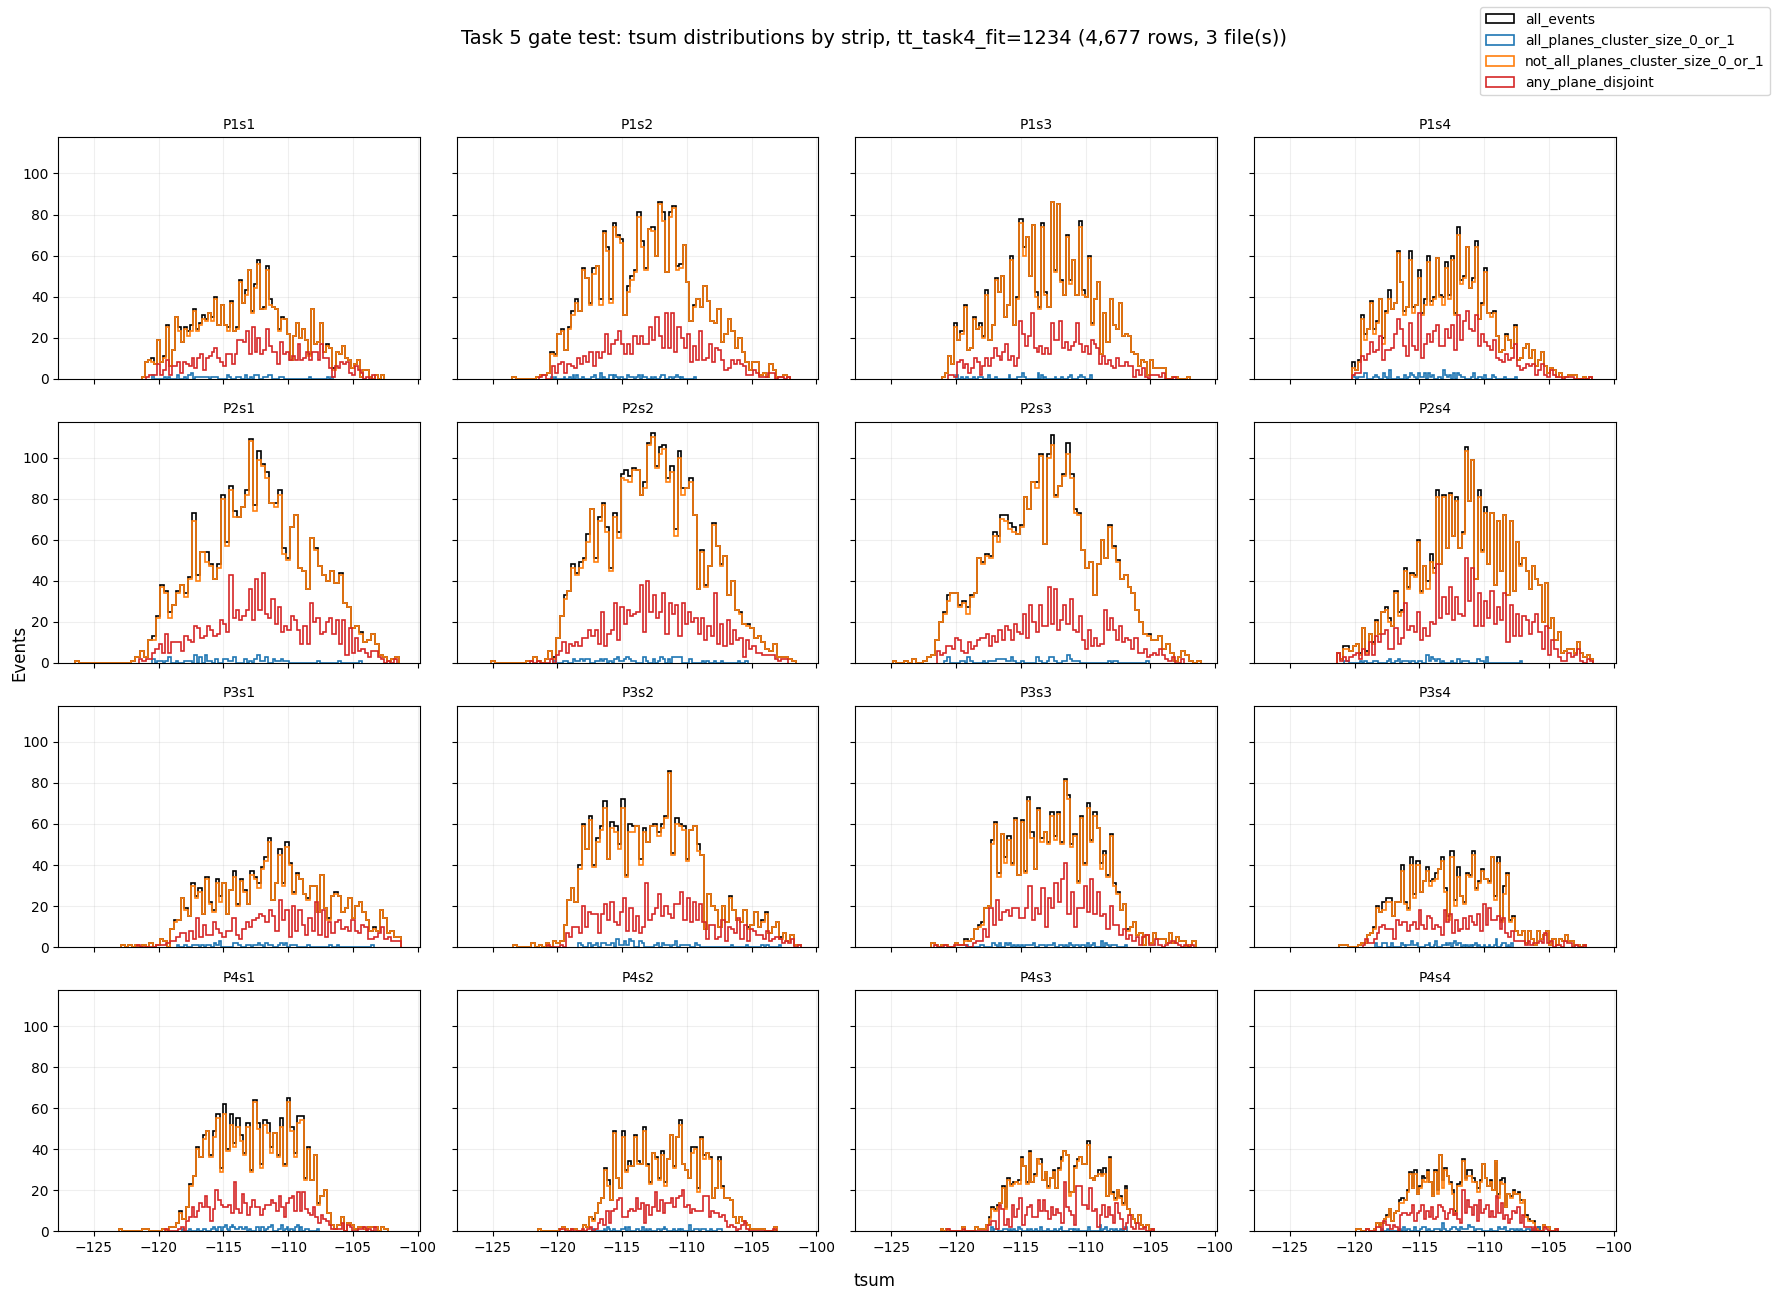

In [81]:
TT_VALUES_TO_PLOT = [1234]  # Example: [1234, 234]

plot_tsum_by_tt(tt_values=TT_VALUES_TO_PLOT)


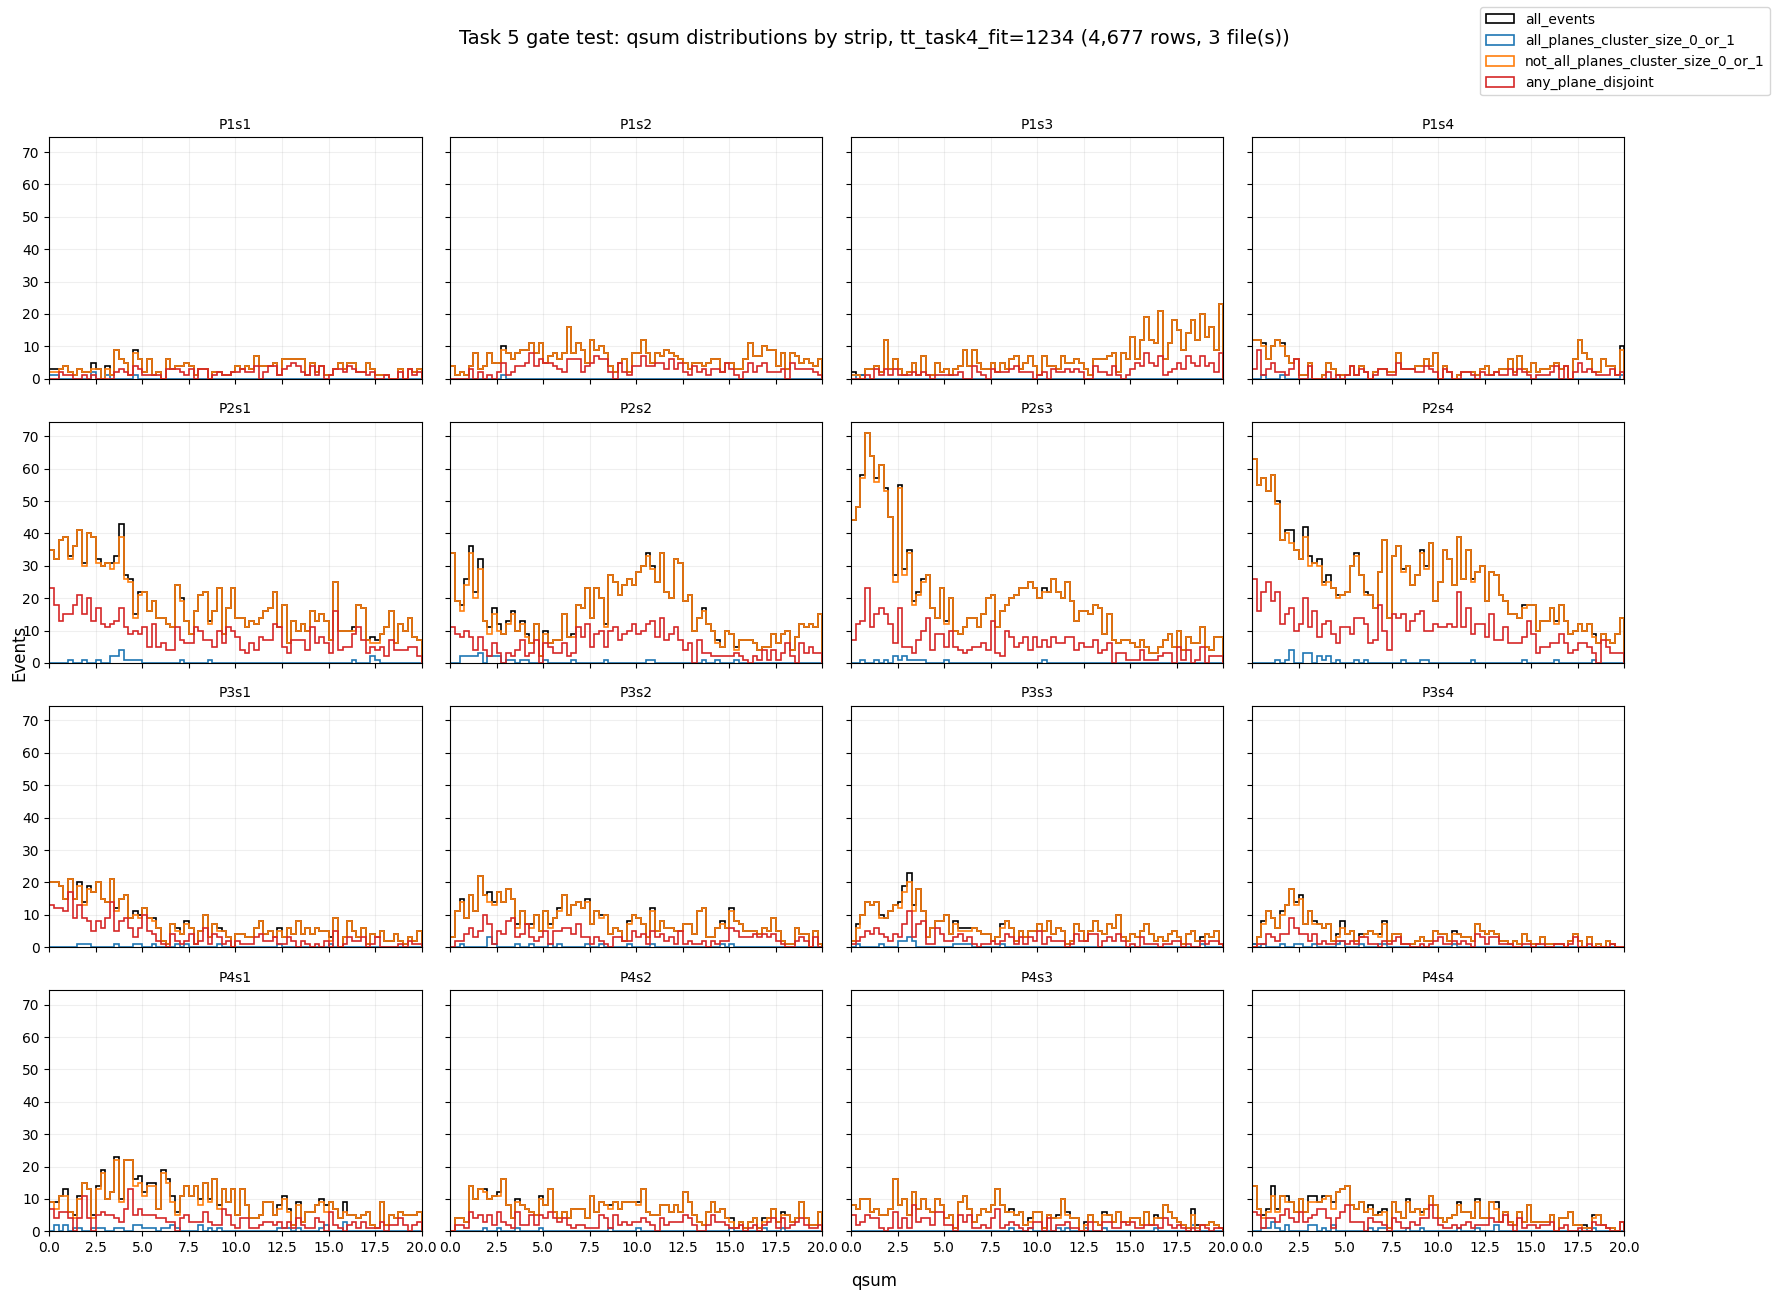

In [82]:

plot_qsum_by_tt(tt_values=TT_VALUES_TO_PLOT)


In [ ]:

plot_tdif_by_tt(tt_values=TT_VALUES_TO_PLOT)

## 7. Strip vs Plane Variable Scatter Plots

These helpers make one 4x4 figure per `tt_task4_fit` plane combination. In each panel, the x-axis is the plane-level variable `p{plane}_{kind}` and the y-axis is the strip-level variable `p{plane}_s{strip}_{kind}`. Gates are overlaid with different colors. Zero and non-finite points are skipped.

In [ ]:
def plane_value_column(df_in: pd.DataFrame, plane: int, value_kind: str) -> str | None:
    column = f"p{plane}_{value_kind.lower().strip()}"
    return column if column in df_in.columns else None


def strip_value_column(df_in: pd.DataFrame, plane: int, strip: int, value_kind: str) -> str | None:
    column = f"p{plane}_s{strip}_{value_kind.lower().strip()}"
    return column if column in df_in.columns else None


def print_strip_vs_plane_column_map(dataframe: pd.DataFrame):
    print("Scatter plots use only explicit canonical p-columns. No fallback columns are used.")
    for value_kind in ("qsum", "qdif", "tsum", "tdif"):
        print(f"\n{value_kind}:")
        for plane in range(1, 5):
            plane_column = plane_value_column(dataframe, plane, value_kind)
            strip_columns = [strip_value_column(dataframe, plane, strip, value_kind) for strip in range(1, 5)]
            print(f"  P{plane}: plane={plane_column} strips={strip_columns}")

def plot_strip_vs_plane_by_tt(
    dataframe: pd.DataFrame,
    *,
    value_kind: str,
    tt_column: str = "tt_task4_fit",
    tt_values: list[int] | None = None,
    gate_labels: list[str] | None = None,
    max_points_per_gate: int | None = 40_000,
    alpha: float = 0.25,
    point_size: float = 2.0,
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
):
    value_kind = value_kind.lower().strip()
    if value_kind not in {"qsum", "qdif", "tsum", "tdif"}:
        raise ValueError("value_kind must be one of: qsum, qdif, tsum, tdif")
    if gate_labels is None:
        gate_labels = [gate["label"] for gate in gate_definitions]
    if tt_values is None:
        tt_values = sorted_tt_values(dataframe, tt_column=tt_column)

    tt_series = pd.to_numeric(dataframe[tt_column], errors="coerce")
    for tt_value in tt_values:
        tt_mask = tt_series.eq(int(tt_value))
        n_tt = int(tt_mask.sum())
        if n_tt == 0:
            print(f"Skipping {tt_column}={tt_value}: no rows.")
            continue

        fig, axes = plt.subplots(4, 4, figsize=(18, 13), sharex=True, sharey=True)
        for plane in range(1, 5):
            plane_column = plane_value_column(dataframe, plane, value_kind)
            for strip in range(1, 5):
                ax = axes[plane - 1, strip - 1]
                strip_column = strip_value_column(dataframe, plane, strip, value_kind)
                ax.set_title(f"P{plane}s{strip}", fontsize=10)
                if plane_column is None or strip_column is None:
                    missing = []
                    if plane_column is None:
                        missing.append(f"p{plane}_{value_kind}")
                    if strip_column is None:
                        missing.append(f"p{plane}_s{strip}_{value_kind}")
                    ax.text(0.5, 0.5, "missing\n" + "\n".join(missing), ha="center", va="center", transform=ax.transAxes)
                    ax.grid(alpha=0.2)
                    continue

                for gate_label in gate_labels:
                    mask = tt_mask & gate_mask_for_label(dataframe, gate_label)
                    x = pd.to_numeric(dataframe.loc[mask, plane_column], errors="coerce").to_numpy(dtype=float)
                    y = pd.to_numeric(dataframe.loc[mask, strip_column], errors="coerce").to_numpy(dtype=float)
                    valid = np.isfinite(x) & np.isfinite(y) & (x != 0.0) & (y != 0.0)
                    if not np.any(valid):
                        continue
                    x = x[valid]
                    y = y[valid]

                    cond = x != y
                    x = x[cond]
                    y = y[cond]

                    cond = (x > 1) & (y > 1)
                    x = x[cond]
                    y = y[cond]

                    if max_points_per_gate is not None and x.size > max_points_per_gate:
                        rng = np.random.default_rng(1)
                        keep = rng.choice(x.size, size=int(max_points_per_gate), replace=False)
                        x = x[keep]
                        y = y[keep]

                    ax.scatter(
                        x,
                        y,
                        s=point_size,
                        alpha=alpha,
                        color=GATE_COLORS.get(gate_label),
                        label=gate_label,
                        rasterized=True,
                    )
                if xlim is not None:
                    ax.set_xlim(*xlim)
                if ylim is not None:
                    ax.set_ylim(*ylim)
                ax.grid(alpha=0.2)

        handles, labels = axes[0, 0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc="upper right", frameon=True)
        fig.suptitle(
            f"Task 5 gate test: strip {value_kind} vs plane {value_kind}, {tt_column}={tt_value} "
            f"({n_tt:,} rows, {len(selected_paths)} file(s))",
            fontsize=14,
        )
        fig.supxlabel(f"plane {value_kind}: p{{plane}}_{value_kind}")
        fig.supylabel(f"strip {value_kind}: p{{plane}}_s{{strip}}_{value_kind}")
        fig.tight_layout(rect=(0, 0, 0.93, 0.95))
        plt.show()


def plot_qsum_strip_vs_plane_by_tt(**kwargs):
    return plot_strip_vs_plane_by_tt(df_gated, value_kind="qsum", **kwargs)


def plot_qdif_strip_vs_plane_by_tt(**kwargs):
    return plot_strip_vs_plane_by_tt(df_gated, value_kind="qdif", **kwargs)


def plot_tsum_strip_vs_plane_by_tt(**kwargs):
    return plot_strip_vs_plane_by_tt(df_gated, value_kind="tsum", **kwargs)


def plot_tdif_strip_vs_plane_by_tt(**kwargs):
    return plot_strip_vs_plane_by_tt(df_gated, value_kind="tdif", **kwargs)


### Scatter Plot Column Map

Run this once to confirm which columns the scatter plots use.

In [ ]:
print_strip_vs_plane_column_map(df_gated)


## 8. Make Strip-vs-Plane Scatter Figures

Run this cell after the helpers above.

In [ ]:
TT_VALUES_TO_PLOT = [1234]  # Example: [13, 23, 1234]; use None for all combinations.

plot_qsum_strip_vs_plane_by_tt(tt_values=TT_VALUES_TO_PLOT)

In [ ]:


plot_qdif_strip_vs_plane_by_tt(tt_values=TT_VALUES_TO_PLOT)
plot_tsum_strip_vs_plane_by_tt(tt_values=TT_VALUES_TO_PLOT)
plot_tdif_strip_vs_plane_by_tt(tt_values=TT_VALUES_TO_PLOT)


## 9. Plane Charge Histograms by Plane Cluster Size

For `tt_task4_fit = 1234`, this plot uses columns P1-P4 and rows equal to the cluster size in that same plane. Each panel overlays the selected gates with different colors. The charge column is explicit: `p{plane}_qsum`.

In [83]:
def plot_plane_charge_histograms_by_cluster_size(
    dataframe: pd.DataFrame,
    *,
    tt_value: int = 1234,
    tt_column: str = "tt_task4_fit",
    gate_labels: list[str] | None = None,
    cluster_sizes: list[int] | None = None,
    bins: int = 80,
    xlim: tuple[float, float] | None = None,
    density: bool = False,
    max_points_per_gate: int | None = 200_000,
):
    if tt_column not in dataframe.columns:
        raise KeyError(f"Missing {tt_column!r}; cannot select plane combination {tt_value}.")
    if gate_labels is None:
        gate_labels = [gate["label"] for gate in gate_definitions]

    tt_series = pd.to_numeric(dataframe[tt_column], errors="coerce")
    tt_mask = tt_series.eq(int(tt_value))
    n_tt = int(tt_mask.sum())
    if n_tt == 0:
        print(f"No rows with {tt_column}={tt_value}.")
        return

    if cluster_sizes is None:
        observed = set()
        for plane in range(1, 5):
            cluster_col = f"gate_p{plane}_cluster_size"
            if cluster_col in dataframe.columns:
                vals = pd.to_numeric(dataframe.loc[tt_mask, cluster_col], errors="coerce").dropna().astype(int)
                observed.update(vals.tolist())
        cluster_sizes = sorted(observed) if observed else [0, 1, 2, 3, 4]
    cluster_sizes = [int(value) for value in cluster_sizes]

    n_rows = max(1, len(cluster_sizes))
    fig, axes = plt.subplots(
        n_rows,
        4,
        figsize=(18, max(3.2 * n_rows, 5)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for row_idx, cluster_size in enumerate(cluster_sizes):
        for plane in range(1, 5):
            ax = axes[row_idx, plane - 1]
            charge_col = f"p{plane}_qsum"
            cluster_col = f"gate_p{plane}_cluster_size"
            ax.set_title(f"P{plane}, cluster size {cluster_size}", fontsize=10)

            if charge_col not in dataframe.columns or cluster_col not in dataframe.columns:
                missing = []
                if charge_col not in dataframe.columns:
                    missing.append(charge_col)
                if cluster_col not in dataframe.columns:
                    missing.append(cluster_col)
                ax.text(0.5, 0.5, "missing\n" + "\n".join(missing), ha="center", va="center", transform=ax.transAxes)
                ax.grid(alpha=0.2)
                continue

            cluster_mask = pd.to_numeric(dataframe[cluster_col], errors="coerce").eq(cluster_size)
            for gate_label in gate_labels:
                mask = tt_mask & cluster_mask & gate_mask_for_label(dataframe, gate_label)
                values = pd.to_numeric(dataframe.loc[mask, charge_col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
                if xlim is not None:
                    values = values.clip(lower=xlim[0], upper=xlim[1])
                if max_points_per_gate is not None and len(values) > max_points_per_gate:
                    values = values.sample(max_points_per_gate, random_state=1)
                if values.empty:
                    continue
                ax.hist(
                    values.to_numpy(dtype=float),
                    bins=bins,
                    range=xlim,
                    histtype="step",
                    linewidth=1.2,
                    density=density,
                    color=GATE_COLORS.get(gate_label),
                    label=gate_label,
                )

            if xlim is not None:
                ax.set_xlim(*xlim)
            ax.grid(alpha=0.2)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right", frameon=True)
    fig.suptitle(
        f"Plane charge p{{plane}}_qsum by per-plane cluster size, {tt_column}={tt_value} "
        f"({n_tt:,} rows, {len(selected_paths)} file(s))",
        fontsize=14,
    )
    fig.supxlabel("Plane charge p{plane}_qsum")
    fig.supylabel("Events" if not density else "Density")
    fig.tight_layout(rect=(0, 0, 0.93, 0.95))
    plt.show()


## 10. Make Plane Charge Cluster-Size Histograms


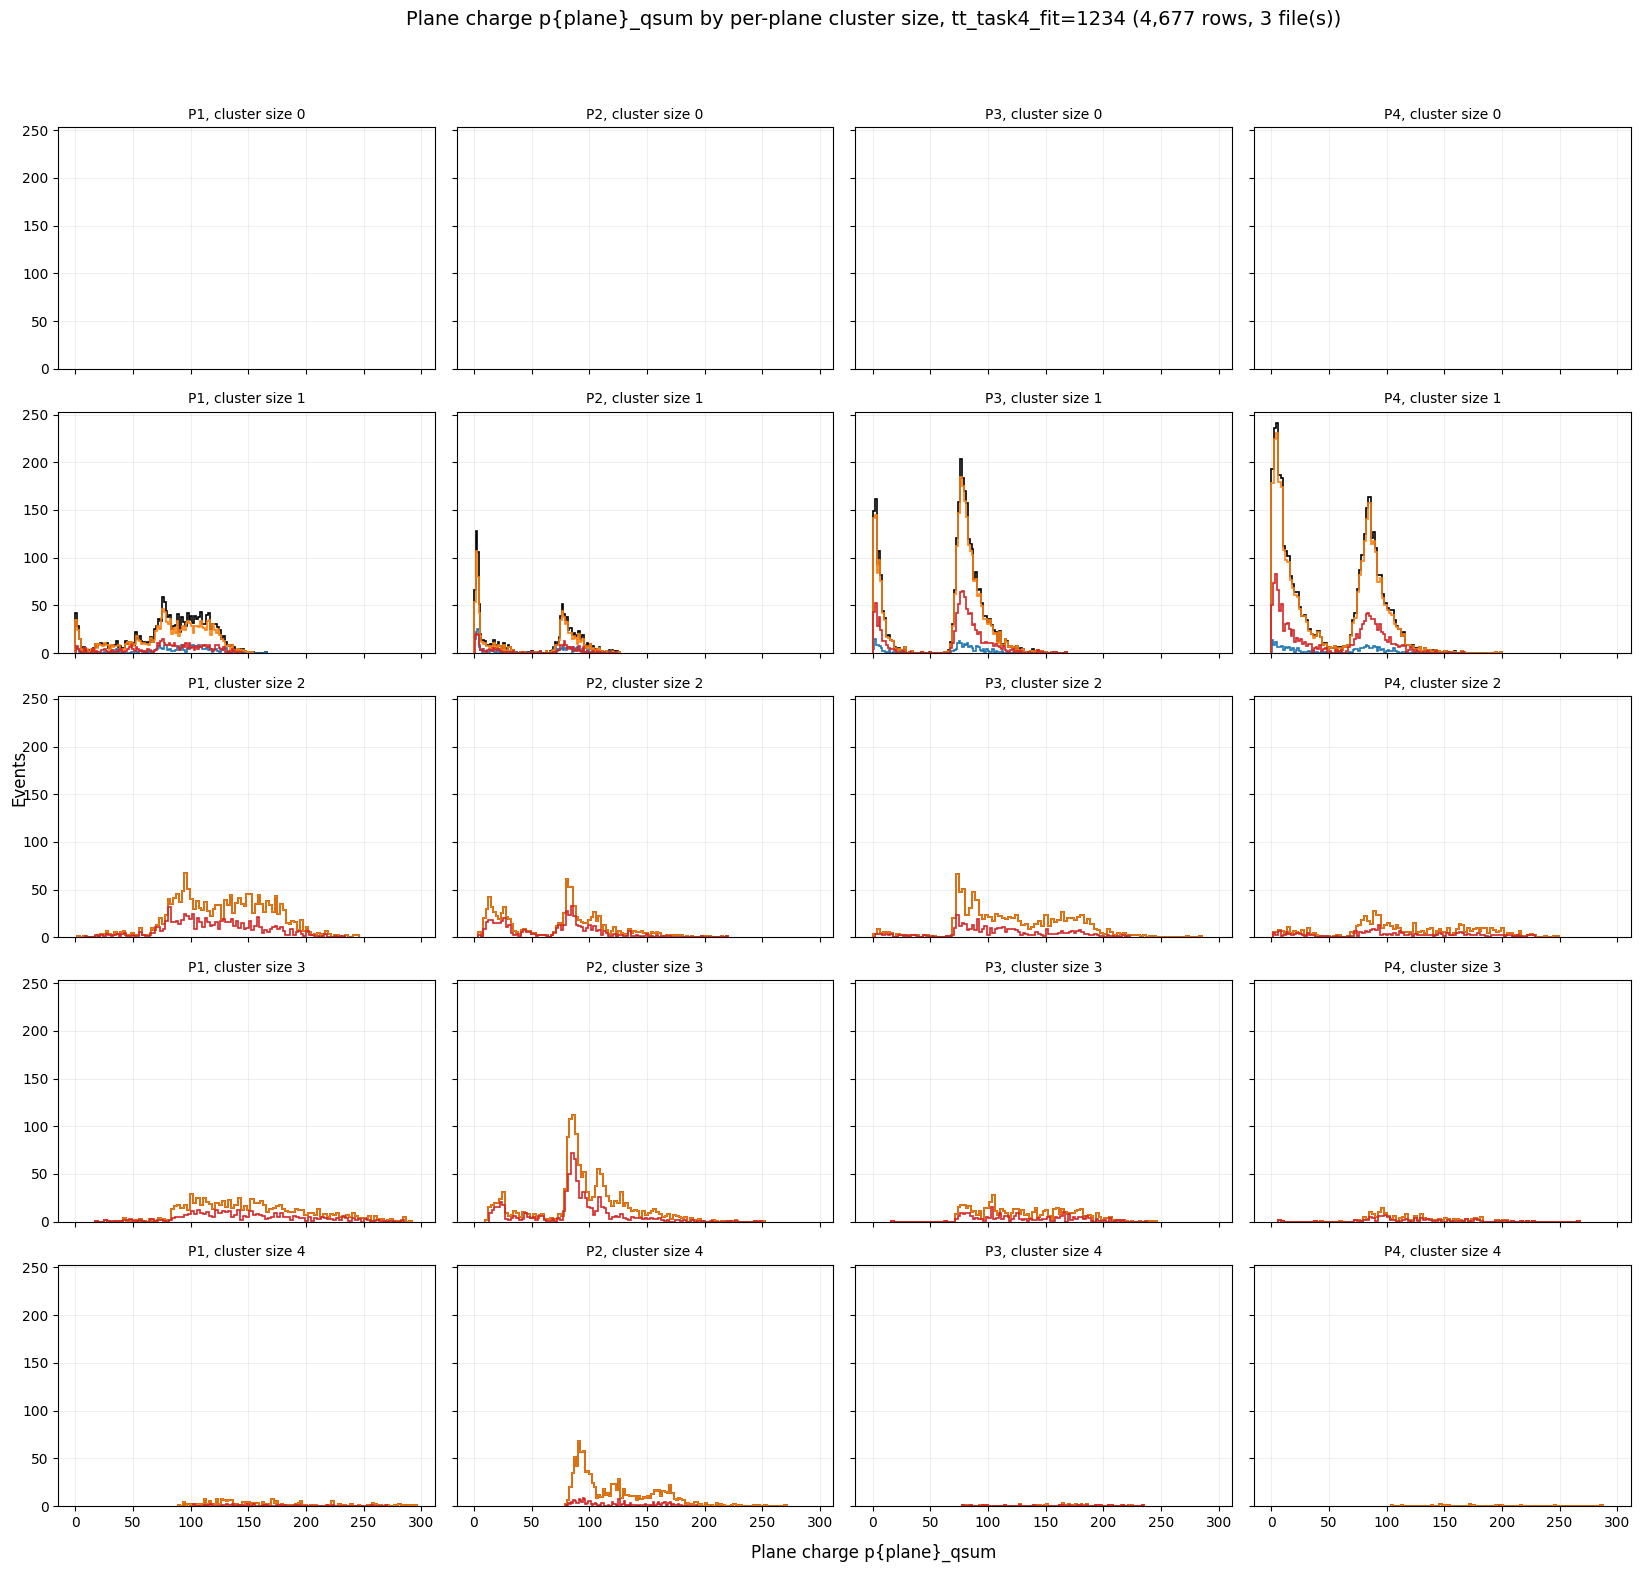

In [84]:
plot_plane_charge_histograms_by_cluster_size(
    df_gated,
    tt_value=1234,
    cluster_sizes=[0, 1, 2, 3, 4],
    bins=100,
    xlim=None,
)
